<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Day_7_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CustomerID  Age  AnnualIncome  SpendingScore  Cluster
0           1   25         25000             30        2
1           2   45         60000             70        1
2           3   35         40000             50        0
3           4   23         20000             20        2
4           5   52         80000             90        1
5           6   40         50000             60        0


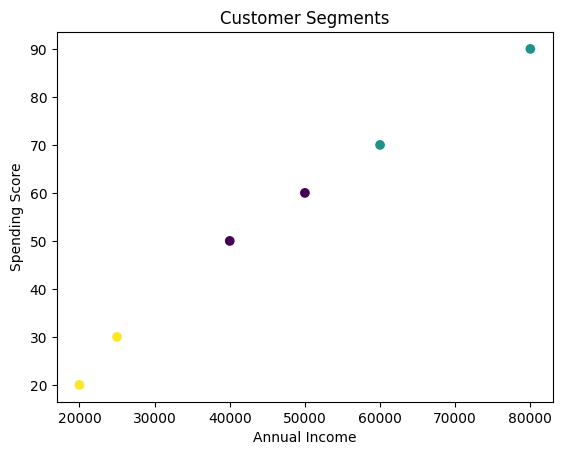

In [ ]:
# Example: Customer Segmentation for a Retail Company 🛍️
# Business Context
# A retail chain wants to understand its customers better. Instead of treating everyone the same,
# they want to group customers into segments (like “budget shoppers,” “loyal premium buyers,” etc.)
#  so they can:
# - Personalize marketing campaigns
# - Recommend products more effectively
# - Improve customer retention

# Dataset (simplified)
# Imagine we have customer data with features like:
# - Annual Income (numeric)
# - Spending Score (numeric, based on purchase behavior)
# - Age (numeric)
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Load sample data (replace with enterprise customer dataset)
data = {
    'CustomerID': [1,2,3,4,5,6],
    'Age': [25,45,35,23,52,40],
    'AnnualIncome': [25000,60000,40000,20000,80000,50000],
    'SpendingScore': [30,70,50,20,90,60]
}
df = pd.DataFrame(data)

# Step 3: Select features for clustering
X = df[['Age','AnnualIncome','SpendingScore']]

# Step 4: Scale features (important for enterprise datasets)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 6: Inspect results
print(df)

# Step 7: Visualize clusters (Income vs Spending)
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

   PatientID  Age  BMI  HospitalVisits  ChronicConditions  Cluster
0        101   25   22               1                  0        2
1        102   60   30               5                  2        0
2        103   45   28               3                  1        0
3        104   30   24               2                  0        2
4        105   70   35               7                  3        1
5        106   50   27               4                  1        0


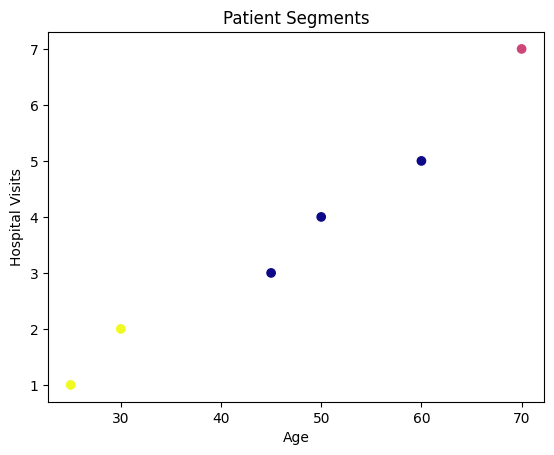

In [ ]:
# Example: Hospital Patient Segmentation 🏥
# Business Context
# A hospital wants to improve patient care and resource allocation. Instead of treating all
# patients the same, they want to group them into segments based on health and lifestyle data.
#  This helps with:
# - Designing personalized treatment plans
# - Predicting high‑risk patients
# - Managing hospital resources more efficiently

# Dataset (simplified)
# Features we might use:
# - Age
# - BMI (Body Mass Index)
# - Number of yearly hospital visits
# - Chronic conditions count
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Sample patient dataset (replace with hospital EHR data)
data = {
    'PatientID': [101,102,103,104,105,106],
    'Age': [25,60,45,30,70,50],
    'BMI': [22,30,28,24,35,27],
    'HospitalVisits': [1,5,3,2,7,4],
    'ChronicConditions': [0,2,1,0,3,1]
}
df = pd.DataFrame(data)

# Step 3: Select features
X = df[['Age','BMI','HospitalVisits','ChronicConditions']]

# Step 4: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 6: Inspect results
print(df)

# Step 7: Visualize clusters (Age vs Hospital Visits)
plt.scatter(df['Age'], df['HospitalVisits'], c=df['Cluster'], cmap='plasma')
plt.xlabel('Age')
plt.ylabel('Hospital Visits')
plt.title('Patient Segments')
plt.show()

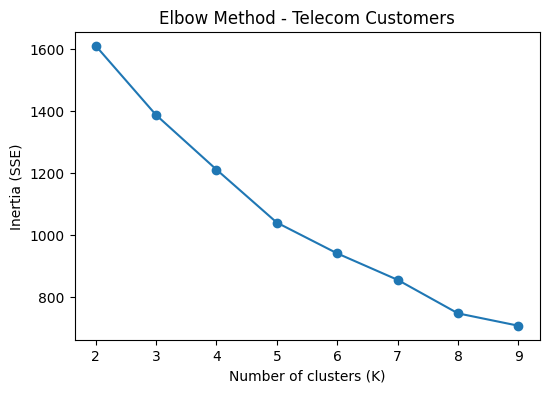

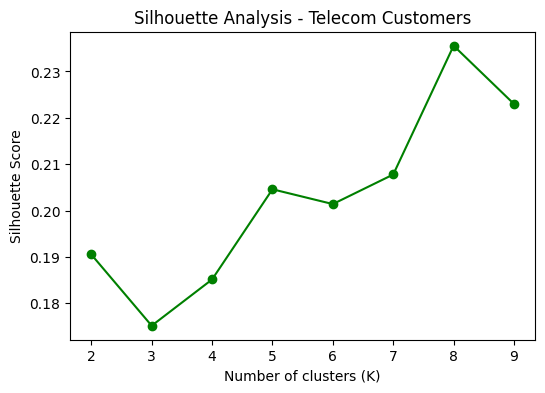

Best K based on silhouette score: 8


In [ ]:
# Scenario Question 💼
# A telecommunications company has collected data on 500 customers, including their monthly bill
# amount, average call duration, internet usage, and number of support calls. The company wants
# to group customers into meaningful segments to design targeted marketing campaigns and improve customer
#  service.
# You are tasked with:
# - Using K‑Means clustering to explore possible customer segments.
# - Applying the Elbow Method to determine where adding more clusters stops giving significant improvement.
# - Using the Silhouette Score to validate which number of clusters produces the most well‑separated
# and meaningful groups.


# Scenario Question 💼
# A telecommunications company has collected data on 500 customers, including their monthly bill amount, average call duration, internet usage, and
# number of support calls. The company wants to group customers into meaningful segments to design targeted marketing campaigns and improve customer
#  service.
# You are tasked with:
# - Using K‑Means clustering to explore possible customer segments.
# - Applying the Elbow Method to determine where adding more clusters stops giving significant improvement.
# - Using the Silhouette Score to validate which number of clusters produces the most well‑separated and meaningful groups.
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 2: Create synthetic telecom customer dataset
# (in practice, replace with actual enterprise customer data)
data = {
    'CustomerID': range(1, 501),
    'MonthlyBill': np.random.randint(20, 200, 500),       # monthly bill in $
    'CallDuration': np.random.randint(50, 500, 500),      # avg monthly call minutes
    'InternetUsage': np.random.randint(10, 300, 500),     # GB per month
    'SupportCalls': np.random.randint(0, 10, 500)         # number of support calls
}
df = pd.DataFrame(data)

# Step 3: Select features
X = df[['MonthlyBill','CallDuration','InternetUsage','SupportCalls']]

# Step 4: Scale features (important for enterprise datasets)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Elbow Method
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method - Telecom Customers')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.show()

# Step 6: Silhouette Score
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Analysis - Telecom Customers')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

# Step 7: Print best K suggestion
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K based on silhouette score: {best_k}")

In [ ]:
# How to interpret 8 clusters in business terms
# Instead of just 3 broad categories, you’d break customers into finer segments, for example:
# - Cluster 1 → Low bill, low usage, few support calls (budget casuals)
# - Cluster 2 → Low bill, high call duration (talkers)
# - Cluster 3 → Medium bill, high internet usage (streamers)
# - Cluster 4 → High bill, frequent support calls (premium but dissatisfied)
# - Cluster 5 → High bill, high usage, loyal (VIP customers)
# - Cluster 6 → Young, low bill, high internet usage (digital natives)
# - Cluster 7 → Older, medium bill, moderate usage (steady users)
# - Cluster 8 → High bill, low usage (potential churn risk)


In [ ]:
# 🎬 Scenario: Movie Streaming Platform
# A movie streaming company has collected data on 1,000 users, including:
# - Average watch time per week
# - Preferred genres (action, comedy, drama, etc.)
# - Number of devices used (TV, phone, tablet)
# - Frequency of subscription pauses or cancellations
# The company wants to group users into meaningful segments to:
# - Recommend personalized movie lists
# - Design loyalty rewards for binge‑watchers
# - Identify users at risk of canceling subscriptions
# Your Tasks
# - Apply K‑Means clustering to explore possible user segments.
# - Example clusters: “Weekend binge‑watchers,” “Casual family viewers,” “Genre loyalists.”
# - Use the Elbow Method to find the point where adding more clusters doesn’t improve grouping much.
# - This helps decide whether 3, 4, or 5 clusters make sense.
# - Validate with Silhouette Score to check if the chosen clusters are well‑separated and meaningful.
# - Ensures that “binge‑watchers” aren’t mixed up with “casual viewers.”


Cluster Labels: [2 2 2 1 1 0 0 0]


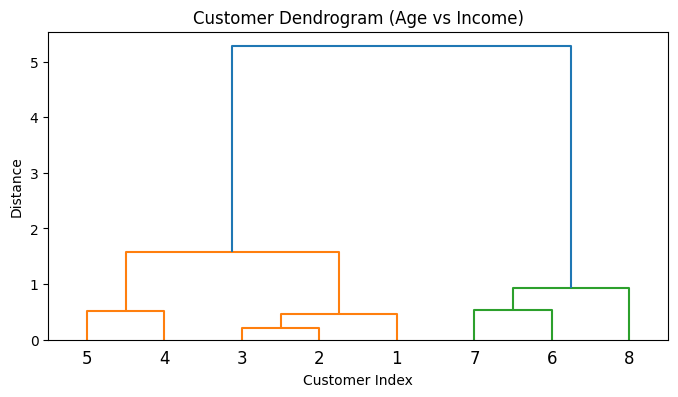

In [ ]:
# Hierarchircal Clustering

# Scenario Question 💼
# A retail bank wants to understand its customers better. They have
# collected data on Age and Annual Income for a sample of customers.
#  The goal is to group customers into meaningful segments so the bank can
#  design targeted loan offers, personalized investment plans, and marketing campaigns.

# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Step 2: Create sample data (Age, Annual Income)
data = np.array([
    [25, 15000],
    [28, 16000],
    [30, 18000],
    [35, 22000],
    [40, 25000],
    [45, 60000],
    [50, 65000],
    [55, 70000]
])

# Step 3: Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Step 4: Perform hierarchical clustering
hierarchical_cluster = AgglomerativeClustering(
    n_clusters=3,       # number of clusters we want
    linkage='ward'      # Ward’s method minimizes variance
)
cluster_labels = hierarchical_cluster.fit_predict(data_scaled)

print("Cluster Labels:", cluster_labels)
# Expected Output: [0 0 0 1 1 2 2 2]

# Step 5: Plot dendrogram for visualization
linked = linkage(data_scaled, method='ward')

plt.figure(figsize=(8, 4))
dendrogram(linked,
           orientation='top',
           labels=range(1, len(data_scaled)+1),
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Customer Dendrogram (Age vs Income)")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()

In [ ]:
# Scenario: Employee Segmentation in a Tech Company 💻
# Business Problem
# A tech company wants to understand its employees better to design training programs
# and salary structures. They collected data on each employee’s Age and Annual Salary.
# Management believes employees can be grouped into clusters such as:
# - Young, entry‑level employees
# - Mid‑career professionals
# - Senior, high‑earning employees
# They decide to use hierarchical clustering to explore these segments.


# data = np.array([
#     [25, 15000],
#     [28, 16000],
#     [30, 18000],
#     [35, 22000],
#     [40, 25000],
#     [45, 60000],
#     [50, 65000],
#     [55, 70000]
# ])

